# Variational Autoencoders — TensorFlow Pipeline

Cross-framework companion to `PyTorch/19-vae/pipeline.ipynb`. TF scope matches the established portfolio pattern (#18 GNN: TF V1+V3; PT all 4): ship the subset of variants that teach the most parity value cross-framework, drop the ones whose primitives don't exercise new TF machinery.

**Planned scope** (pending Phase 0 smoke test below):
- **V1 Vanilla VAE (MNIST)** — confirms reparameterization trick + analytical KL implement identically in TF Dense + `tf.random.normal` + `tf.reduce_sum`
- **V2 Conv VAE (CIFAR-10)** — IF WSL2 TF 2.21's `Conv2D` / `Conv2DTranspose` pass the smoke test below. V2 was skipped in TF for ViT #17 due to a cuDNN "No DNN in stream executor" error on this exact build; we verify before committing.

**Dropped variants** (PT-only, documented in root README):
- V3 β-VAE: single-coefficient change from V1, no new TF primitives
- V4 VQ-VAE: straight-through estimator + codebook as `tf.Variable` is substantial scope for marginal cross-framework value
- V5 VQ-VAE + PixelCNN: masked-convolution subclassing in TF is not a primitive anyone reaches for in practice; DALL-E recipe story is already told in PT

**Parity targets**:
- V1 TF within 3pp NLL of PT V1 on MNIST (PT V1: 101.98 nats)
- V2 TF within 15% FID of PT V2 on CIFAR-10 (PT V2 prior-sampled FID: 165.43)

In [1]:
# Step 0: WSL2 TF 2.21 environment verification + Conv2D smoke test

import os
import sys

# Suppress TF's CUDA registration spam before importing TF
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "1"

import numpy as np
import tensorflow as tf

BASE_DIR = '/mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons'
sys.path.insert(0, BASE_DIR)

# Reproducibility
RANDOM_STATE = 113
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("=" * 60)
print("Phase 0: WSL2 TF environment + primitives smoke test")
print("=" * 60)

# Step 1: TF version + GPU visibility
gpus = tf.config.list_physical_devices('GPU')
print(f"\nTF version: {tf.__version__}")
print(f"GPUs visible: {gpus}")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    DEVICE = '/GPU:0'
    print(f"Memory growth enabled on {DEVICE}")
else:
    DEVICE = '/CPU:0'
    print(f"No GPU -- falling back to CPU")


# Step 2: Dense smoke test (known-good baseline)
print(f"\n[1/4] Dense smoke test on {DEVICE}...")
with tf.device(DEVICE):
    x_dense = tf.random.normal((8, 784))
    y_dense = tf.keras.layers.Dense(400, activation='relu')(x_dense)
    print(f"    Dense(400) on (8, 784) -> {y_dense.shape}  [OK]")


# Step 3: CRITICAL -- Conv2D smoke test (the V2 gatekeeper)
print(f"\n[2/4] Conv2D smoke test on {DEVICE} -- V2 gatekeeper...")
try:
    with tf.device(DEVICE):
        x_conv = tf.random.normal((8, 32, 32, 3))              # CIFAR-10 shape
        conv = tf.keras.layers.Conv2D(32, 4, strides=2, padding='same')
        y_conv = conv(x_conv)
        print(f"    Conv2D(32, 4, stride=2) on (8,32,32,3) -> {y_conv.shape}  [OK]")
        CONV2D_WORKS = True
except Exception as e:
    print(f"    Conv2D FAILED: {type(e).__name__}: {e}")
    CONV2D_WORKS = False


# Step 4: Conv2DTranspose smoke test (V2 decoder gatekeeper)
print(f"\n[3/4] Conv2DTranspose smoke test on {DEVICE}...")
try:
    with tf.device(DEVICE):
        x_up = tf.random.normal((8, 8, 8, 64))
        upconv = tf.keras.layers.Conv2DTranspose(32, 4, strides=2, padding='same')
        y_up = upconv(x_up)
        print(f"    Conv2DTranspose(32, 4, stride=2) on (8,8,8,64) -> {y_up.shape}  [OK]")
        CONVTRANSPOSE_WORKS = True
except Exception as e:
    print(f"    Conv2DTranspose FAILED: {type(e).__name__}: {e}")
    CONVTRANSPOSE_WORKS = False


# Step 5: Data availability check
print(f"\n[4/4] Data file availability...")
mnist_path = os.path.join(BASE_DIR, 'data', 'processed', 'vae', 'mnist')
cifar_path = os.path.join(BASE_DIR, 'data', 'processed', 'vae', 'cifar10')
for name, path in [('MNIST', mnist_path), ('CIFAR-10', cifar_path)]:
    x_train = os.path.join(path, 'X_train.npy')
    if os.path.exists(x_train):
        arr = np.load(x_train, mmap_mode='r')
        print(f"    {name}: {arr.shape} {arr.dtype}  [OK]")
    else:
        print(f"    {name}: MISSING at {x_train}")


# Step 6: Decision summary
print("\n" + "=" * 60)
print("Phase 0 Decision Summary")
print("=" * 60)
print(f"    Dense:           OK")
print(f"    Conv2D:          {'OK  -> V2 can run on WSL2 GPU' if CONV2D_WORKS else 'FAIL -> drop V2 from TF scope'}")
print(f"    Conv2DTranspose: {'OK' if CONVTRANSPOSE_WORKS else 'FAIL'}")
print()
if CONV2D_WORKS and CONVTRANSPOSE_WORKS:
    print("    Scope: V1 MNIST + V2 CIFAR-10 (both feasible on this WSL2 build)")
else:
    print("    Scope: V1 MNIST only (V2 Conv VAE blocked by WSL2 cuDNN Conv2D constraint)")
print("=" * 60)

I0000 00:00:1777056697.267162     618 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777056699.019703     618 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Phase 0: WSL2 TF environment + primitives smoke test

TF version: 2.21.0
GPUs visible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth enabled on /GPU:0

[1/4] Dense smoke test on /GPU:0...
    Dense(400) on (8, 784) -> (8, 400)  [OK]

[2/4] Conv2D smoke test on /GPU:0 -- V2 gatekeeper...
    Conv2D FAILED: InvalidArgumentError: Exception encountered when calling Conv2D.call().

{{function_node __wrapped__Conv2D_device_/job:localhost/replica:0/task:0/device:GPU:0}} No DNN in stream executor. [Op:Conv2D]

Arguments received by Conv2D.call():
  • inputs=tf.Tensor(shape=(8, 32, 32, 3), dtype=float32)

[3/4] Conv2DTranspose smoke test on /GPU:0...
    Conv2DTranspose FAILED: InvalidArgumentError: Exception encountered when calling Conv2DTranspose.call().

{{function_node __wrapped__Conv2DBackpropInput_device_/job:localhost/replica:0/task:0/device:GPU:0}} No DNN in stream executor. [Op:Conv2DBackpropInput]

Arguments received by Conv2DTranspose.call():
  • i

E0000 00:00:1777056701.319277     618 cuda_dnn.cc:454] Loaded runtime CuDNN library: 9.1.0 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
W0000 00:00:1777056701.319739     618 op_kernel.cc:1858] OP_REQUIRES failed at conv_ops_impl.h:1204 : INVALID_ARGUMENT: No DNN in stream executor.
W0000 00:00:1777056701.319775     618 local_rendezvous.cc:412] Local rendezvous is aborting with status: INVALID_ARGUMENT: No DNN in stream executor.
E0000 00:00:1777056701.327555     618 cuda_dnn.cc:454] Loaded runtime CuDNN library: 9.1.0 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources

In [3]:
# Step 2: TF V1 setup -- MNIST load + seeded 90/10 split + TF Datasets
# No new imports: reuses os / numpy / tf / BASE_DIR / RANDOM_STATE from Step 0

print("=" * 60)
print("Step 2: TF V1 Setup -- MNIST + Data Pipeline")
print("=" * 60)

# Step 2.1: V1 hyperparameters (match PT V1 exactly for cross-framework parity)
V1_INPUT_DIM  = 28 * 28
V1_HIDDEN_DIM = 400
V1_LATENT_DIM = 20
V1_BETA       = 1.0
V1_LR         = 1e-3
V1_BATCH_SIZE = 128
V1_EPOCHS     = 50
V1_LOG_EVERY  = 5
V1_VAL_FRAC   = 0.1


# Step 2.2: Load MNIST from the shared .npy cache (verified readable in Step 0)
mnist_dir = os.path.join(BASE_DIR, 'data', 'processed', 'vae', 'mnist')
mnist_X_train = np.load(os.path.join(mnist_dir, 'X_train.npy'))   # (60000, 28, 28)
mnist_y_train = np.load(os.path.join(mnist_dir, 'y_train.npy'))
mnist_X_test  = np.load(os.path.join(mnist_dir, 'X_test.npy'))    # (10000, 28, 28)
mnist_y_test  = np.load(os.path.join(mnist_dir, 'y_test.npy'))

print(f"\nMNIST loaded:")
print(f"    X_train: {mnist_X_train.shape} {mnist_X_train.dtype}")
print(f"    X_test:  {mnist_X_test.shape}  {mnist_X_test.dtype}")
print(f"    Range:   [{mnist_X_train.min():.2f}, {mnist_X_train.max():.2f}]")


# Step 2.3: Seeded 90/10 train/val split
# Numpy RNG != torch RNG, so indices won't match PT V1 exactly. Split size + seed parity preserved.
n_train_full = len(mnist_X_train)
n_val = int(V1_VAL_FRAC * n_train_full)
rng = np.random.RandomState(RANDOM_STATE)
perm = rng.permutation(n_train_full)
val_idx, train_idx = perm[:n_val], perm[n_val:]

X_train_split = mnist_X_train[train_idx]
X_val_split   = mnist_X_train[val_idx]

print(f"\nSplit: train {len(train_idx):,} / val {len(val_idx):,} / test {len(mnist_X_test):,}")


# Step 2.4: TF Dataset pipelines (batch + shuffle + prefetch)
train_ds = (tf.data.Dataset.from_tensor_slices(X_train_split)
            .shuffle(len(train_idx), seed=RANDOM_STATE, reshuffle_each_iteration=True)
            .batch(V1_BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))
val_ds = (tf.data.Dataset.from_tensor_slices(X_val_split)
          .batch(V1_BATCH_SIZE)
          .prefetch(tf.data.AUTOTUNE))
test_ds = (tf.data.Dataset.from_tensor_slices(mnist_X_test)
           .batch(V1_BATCH_SIZE)
           .prefetch(tf.data.AUTOTUNE))


# Step 2.5: Results dir + variant container
RESULTS_DIR = os.path.join(BASE_DIR, 'TensorFlow', '19-vae', 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

mnist_variants = []

print(f"\nResults dir: {RESULTS_DIR}")
print(f"Variant container initialized: mnist_variants = []")

Step 2: TF V1 Setup -- MNIST + Data Pipeline

MNIST loaded:
    X_train: (60000, 28, 28) float32
    X_test:  (10000, 28, 28)  float32
    Range:   [0.00, 1.00]

Split: train 54,000 / val 6,000 / test 10,000

Results dir: /mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/TensorFlow/19-vae/results
Variant container initialized: mnist_variants = []


In [4]:
# Step 3: V1 VAELinear Keras Model subclass + vae_loss + training loop

from utils.performance import track_performance

print("=" * 60)
print("Step 3: V1 VAELinear -- Model Definition + Training")
print("=" * 60)


# Step 3.1: VAELinear model -- Keras Model subclass mirroring PT 
class VAELinear(tf.keras.Model):
    """
    MLP VAE, TF port of PyTorch V1.
    Encoder: Flatten -> Dense(400, relu) -> (mu_20, logvar_20) heads.
    Decoder: Dense(400, relu) -> Dense(784, sigmoid) for Bernoulli likelihood.
    """
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20, **kwargs):
        super().__init__(**kwargs)
        self.input_dim = input_dim
        self.latent_dim = latent_dim

        # Encoder -- shared hidden trunk + split mu/logvar heads
        self.enc_fc1    = tf.keras.layers.Dense(hidden_dim, activation='relu', name='enc_fc1')
        self.enc_mu     = tf.keras.layers.Dense(latent_dim, name='enc_mu')
        self.enc_logvar = tf.keras.layers.Dense(latent_dim, name='enc_logvar')

        # Decoder -- sigmoid output for BCE reconstruction (Bernoulli likelihood)
        self.dec_fc1 = tf.keras.layers.Dense(hidden_dim, activation='relu', name='dec_fc1')
        self.dec_fc2 = tf.keras.layers.Dense(input_dim, activation='sigmoid', name='dec_fc2')

    def encode(self, x):
        x_flat = tf.reshape(x, [-1, self.input_dim])
        h = self.enc_fc1(x_flat)
        return self.enc_mu(h), self.enc_logvar(h)

    def reparameterize(self, mu, logvar):
        # z = mu + exp(0.5 * logvar) * eps, eps ~ N(0, I) -- trick that makes the
        # stochastic encoder differentiable. Matches PT's `reparameterize` helper.
        eps = tf.random.normal(tf.shape(mu))
        return mu + tf.exp(0.5 * logvar) * eps

    def decode(self, z):
        h = self.dec_fc1(z)
        return self.dec_fc2(h)

    def call(self, x, training=False):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


# Step 3.2: vae_loss -- BCE sum-over-pixels + analytical KL sum-over-latent, mean batch
def vae_loss(x, x_recon, mu, logvar, beta=1.0):
    """
    ELBO loss matching PT V1 semantics:
      BCE: sum over pixels per sample (per-sample scale), then mean over batch
      KL:  analytical Gaussian-vs-N(0,I), sum over latent dim per sample, mean batch
    Returns (total_nll, bce_per_sample, kl_per_sample) as scalars.
    """
    x_flat = tf.reshape(x, [-1, tf.shape(x_recon)[-1]])
    eps = 1e-8
    # Per-sample BCE sum over pixels
    bce_per_sample = -tf.reduce_sum(
        x_flat * tf.math.log(x_recon + eps) +
        (1.0 - x_flat) * tf.math.log(1.0 - x_recon + eps),
        axis=1,
    )
    # Per-sample KL sum over latent dims
    kl_per_sample = -0.5 * tf.reduce_sum(
        1.0 + logvar - tf.square(mu) - tf.exp(logvar),
        axis=1,
    )
    total_nll = tf.reduce_mean(bce_per_sample + beta * kl_per_sample)
    return total_nll, tf.reduce_mean(bce_per_sample), tf.reduce_mean(kl_per_sample)


# Step 3.3: Instantiate model, build weights, optimizer, sanity check
tf.random.set_seed(RANDOM_STATE)
model_v1 = VAELinear(V1_INPUT_DIM, V1_HIDDEN_DIM, V1_LATENT_DIM)
# Build the weights by calling once on a dummy input (Keras subclassed models
# are lazy-built -- no parameters exist until first forward pass)
_ = model_v1(tf.zeros((1, 28, 28)))

optimizer = tf.keras.optimizers.Adam(learning_rate=V1_LR)
num_params = int(np.sum([np.prod(w.shape) for w in model_v1.trainable_variables]))

# Sanity: forward pass shapes
x_sanity = tf.random.normal((4, 28, 28))
xr, mu_s, lv_s = model_v1(x_sanity)
print(f"\nModel: VAELinear(in={V1_INPUT_DIM}, hidden={V1_HIDDEN_DIM}, latent={V1_LATENT_DIM})")
print(f"    Params: {num_params:,}")
print(f"    Sanity: x_recon {tuple(xr.shape)}, mu {tuple(mu_s.shape)}, logvar {tuple(lv_s.shape)}  [OK]")
del x_sanity, xr, mu_s, lv_s


# Step 3.4: Training loop with best-val snapshot
history = {
    'train_loss': [], 'train_recon': [], 'train_kl': [],
    'val_loss':   [], 'val_recon':   [], 'val_kl':   [],
}
best_val = float('inf')
best_weights = None

print(f"\nTraining V1 VAE on MNIST ({V1_EPOCHS} epochs, batch={V1_BATCH_SIZE})...")
with track_performance(gpu=True) as perf:
    for epoch in range(V1_EPOCHS):
        # Train
        tl = tr = tk = 0.0; n = 0
        for batch in train_ds:
            with tf.GradientTape() as tape:
                x_recon, mu, logvar = model_v1(batch, training=True)
                loss, recon, kl = vae_loss(batch, x_recon, mu, logvar, beta=V1_BETA)
            grads = tape.gradient(loss, model_v1.trainable_variables)
            optimizer.apply_gradients(zip(grads, model_v1.trainable_variables))
            b = int(tf.shape(batch)[0])
            tl += float(loss) * b; tr += float(recon) * b; tk += float(kl) * b
            n += b
        tl /= n; tr /= n; tk /= n

        # Val
        vl = vr = vk = 0.0; n = 0
        for batch in val_ds:
            x_recon, mu, logvar = model_v1(batch, training=False)
            loss, recon, kl = vae_loss(batch, x_recon, mu, logvar, beta=V1_BETA)
            b = int(tf.shape(batch)[0])
            vl += float(loss) * b; vr += float(recon) * b; vk += float(kl) * b
            n += b
        vl /= n; vr /= n; vk /= n

        history['train_loss'].append(tl); history['train_recon'].append(tr); history['train_kl'].append(tk)
        history['val_loss'].append(vl);   history['val_recon'].append(vr);   history['val_kl'].append(vk)

        # Best-val snapshot -- store numpy copies of every trainable weight
        if vl < best_val:
            best_val = vl
            best_weights = [w.numpy() for w in model_v1.trainable_variables]

        if (epoch + 1) % V1_LOG_EVERY == 0 or epoch == 0:
            print(f"    ep {epoch + 1:3d}: train_nll={tl:.2f} (recon={tr:.2f}, kl={tk:.2f}) | "
                  f"val_nll={vl:.2f} (recon={vr:.2f}, kl={vk:.2f})")

print(f"\n    Train time: {perf['time']:.1f}s, peak GPU memory: {perf['gpu_memory']:.1f} MB")
print(f"    Best val NLL: {best_val:.2f} nats (PT V1 reference: 103.22)")


# Step 3.5: Restore best weights to the live model
for w, bw in zip(model_v1.trainable_variables, best_weights):
    w.assign(bw)
print(f"    Best weights restored -- model_v1 now holds the best-val checkpoint")

/home/max/tf-gpu-venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Step 3: V1 VAELinear -- Model Definition + Training

Model: VAELinear(in=784, hidden=400, latent=20)
    Params: 652,824
    Sanity: x_recon (4, 784), mu (4, 20), logvar (4, 20)  [OK]

Training V1 VAE on MNIST (50 epochs, batch=128)...
    ep   1: train_nll=167.92 (recon=149.75, kl=18.17) | val_nll=131.22 (recon=109.44, kl=21.78)
    ep   5: train_nll=111.19 (recon=86.46, kl=24.73) | val_nll=110.62 (recon=85.41, kl=25.21)
    ep  10: train_nll=106.83 (recon=81.63, kl=25.20) | val_nll=107.23 (recon=82.05, kl=25.18)
    ep  15: train_nll=105.18 (recon=79.82, kl=25.36) | val_nll=105.87 (recon=80.34, kl=25.53)
    ep  20: train_nll=104.27 (recon=78.87, kl=25.40) | val_nll=105.01 (recon=80.34, kl=24.67)
    ep  25: train_nll=103.61 (recon=78.16, kl=25.45) | val_nll=104.41 (recon=79.19, kl=25.22)
    ep  30: train_nll=103.13 (recon=77.66, kl=25.47) | val_nll=103.97 (recon=78.61, kl=25.36)
    ep  35: train_nll=102.82 (recon=77.32, kl=25.50) | val_nll=103.81 (recon=78.47, kl=25.33)
    ep  40

Step 4: V1 Evaluation + Visualizations

[1/6] Test evaluation...
    Test NLL:   102.09 nats/sample  (recon=76.75, kl=25.34)
    PT V1 ref:  101.98 nats  |  parity target: within 3pp
    Parity delta: +0.11 nats  (PASS)
    TF peak GPU memory (cumulative since kernel start): 544.4 MB

[2/6] Reconstruction grid...


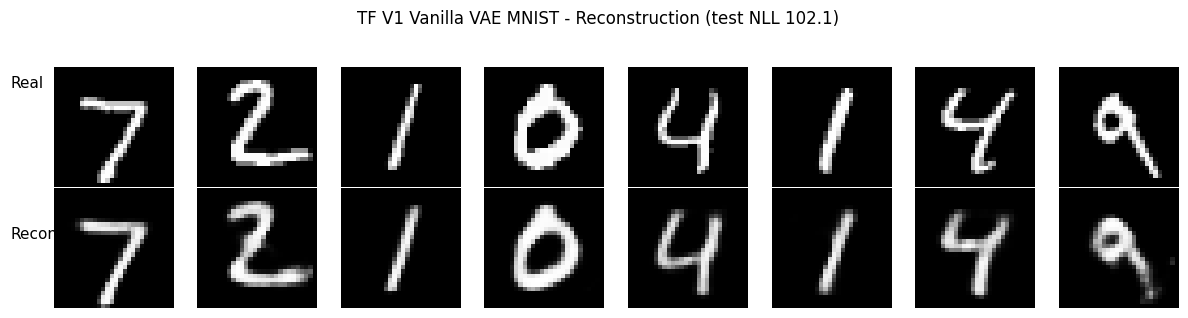


[3/6] Generated samples (64 draws from prior)...


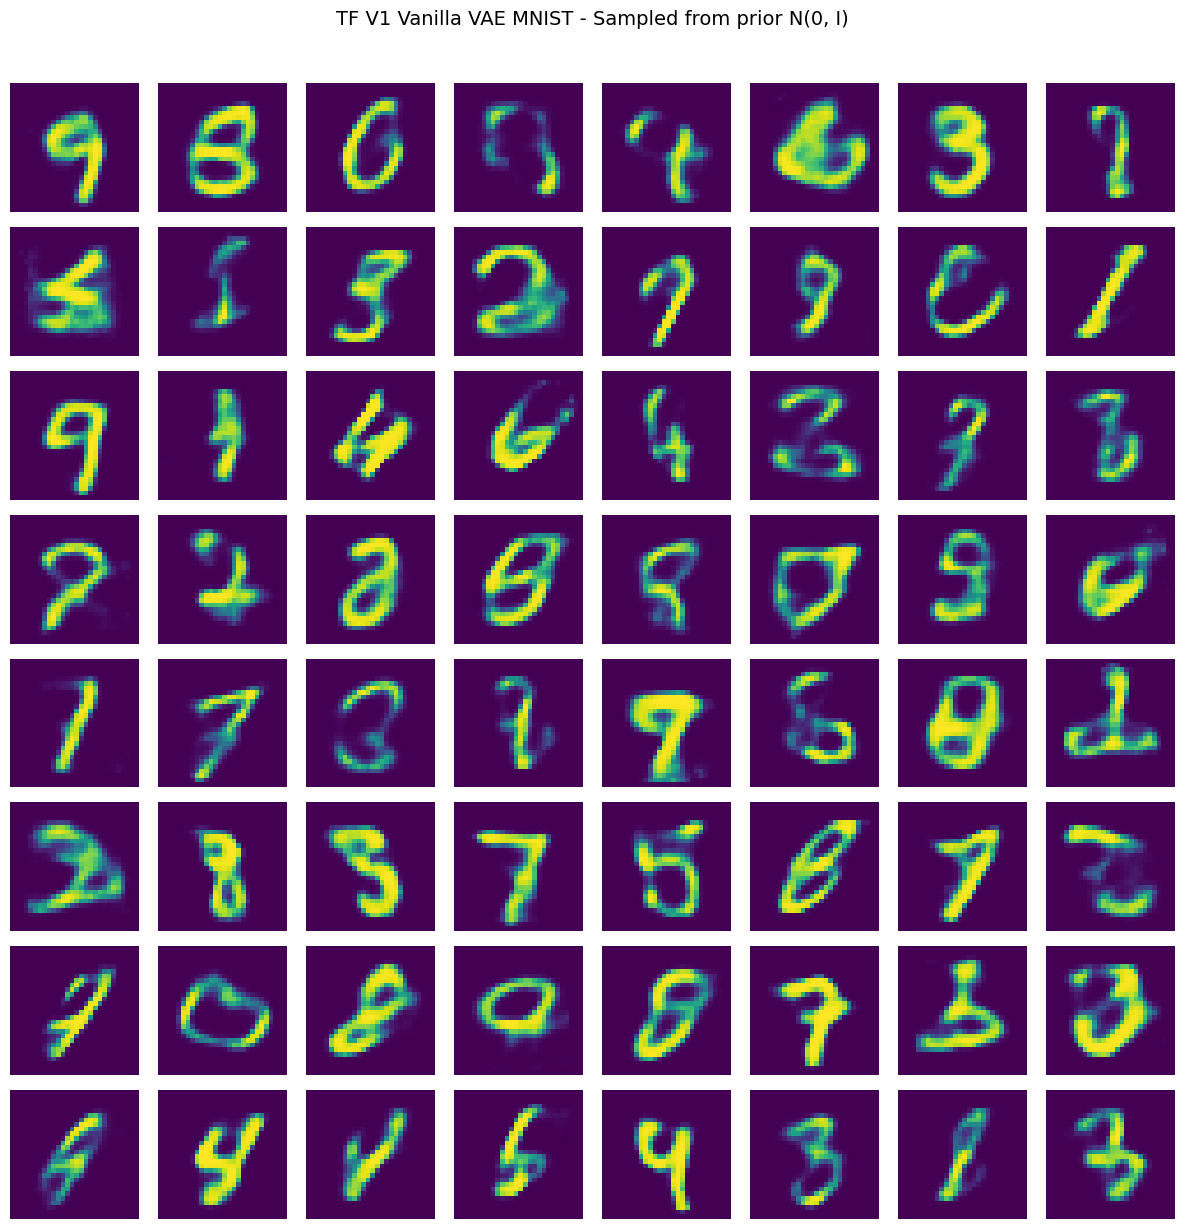


[4/6] Latent interpolation...


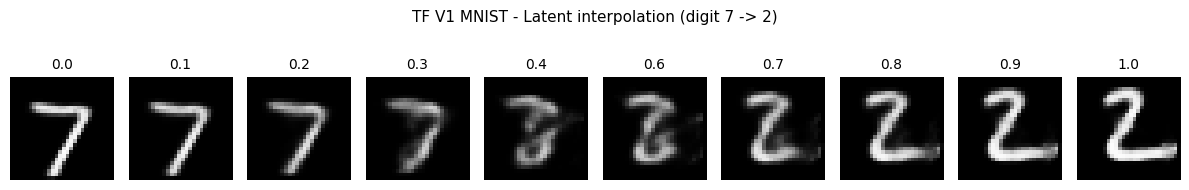


[5/6] Latent space t-SNE (this takes ~30s on 10K samples)...


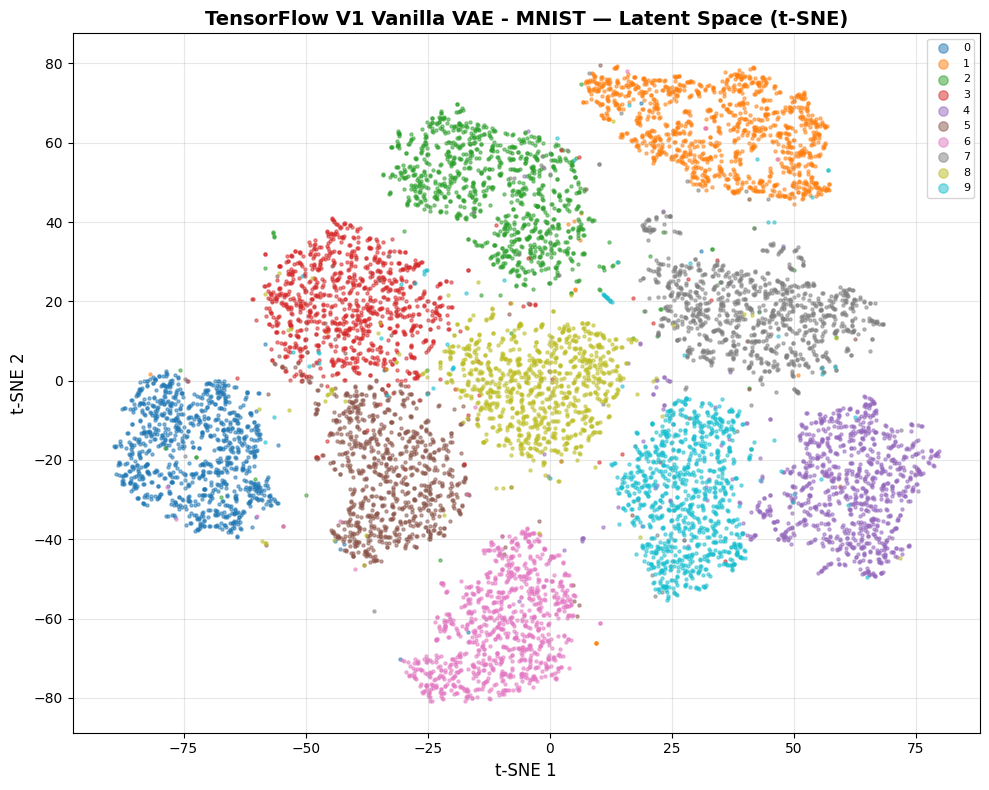


[6/6] Training history...


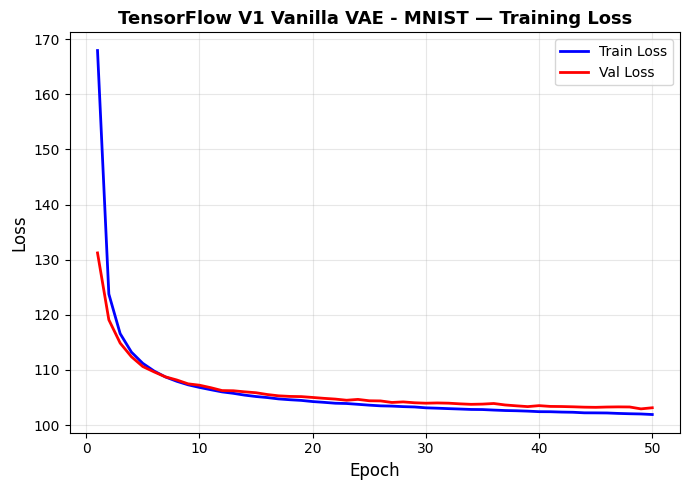

In [5]:
# Step 4: Test evaluation + reconstruction/samples/interpolation/latent/history plots

import matplotlib.pyplot as plt
from utils.visualization import plot_generated_grid, plot_latent_space, plot_training_history

print("=" * 60)
print("Step 4: V1 Evaluation + Visualizations")
print("=" * 60)


# Step 4.1: Test loop -- NLL/recon/KL + collect mu values for t-SNE
print("\n[1/6] Test evaluation...")
test_loss = test_recon = test_kl = 0.0; n = 0
all_mu = []
for batch in test_ds:
    x_recon, mu, logvar = model_v1(batch, training=False)
    loss, recon, kl = vae_loss(batch, x_recon, mu, logvar, beta=V1_BETA)
    b = int(tf.shape(batch)[0])
    test_loss  += float(loss)  * b
    test_recon += float(recon) * b
    test_kl    += float(kl)    * b
    n += b
    all_mu.append(mu.numpy())
test_loss /= n; test_recon /= n; test_kl /= n
test_mus = np.concatenate(all_mu, axis=0)   # (10000, 20)

print(f"    Test NLL:   {test_loss:.2f} nats/sample  (recon={test_recon:.2f}, kl={test_kl:.2f})")
print(f"    PT V1 ref:  101.98 nats  |  parity target: within 3pp")
print(f"    Parity delta: {test_loss - 101.98:+.2f} nats  "
      f"({'PASS' if abs(test_loss - 101.98) <= 3.0 else 'FAIL'})")


# Step 4.2: Manual TF GPU peak memory (track_performance in Step 3 mis-detected torch)
peak_gpu_mb = tf.config.experimental.get_memory_info('GPU:0')['peak'] / 1024 / 1024
print(f"    TF peak GPU memory (cumulative since kernel start): {peak_gpu_mb:.1f} MB")


# Step 4.3: Reconstruction grid (inline plt, matching PT V1's 2x8 real-vs-recon layout)
print("\n[2/6] Reconstruction grid...")
x_sample = mnist_X_test[:8]                                          # (8, 28, 28)
x_recon_sample, _, _ = model_v1(x_sample, training=False)
x_recon_sample = tf.reshape(x_recon_sample, [-1, 28, 28]).numpy()

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i in range(8):
    axes[0, i].imshow(x_sample[i],       cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].imshow(x_recon_sample[i], cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')
fig.text(0.01, 0.75, 'Real',  va='center', fontsize=11)
fig.text(0.01, 0.28, 'Recon', va='center', fontsize=11)
fig.suptitle(f'TF V1 Vanilla VAE MNIST - Reconstruction (test NLL {test_loss:.1f})', fontsize=12)
plt.tight_layout(rect=[0.03, 0, 1, 0.95])
plt.savefig(os.path.join(RESULTS_DIR, 'v1_vanilla_mnist_recon.png'), dpi=150, bbox_inches='tight')
plt.show()


# Step 4.4: 64 samples from the N(0, I) prior
print("\n[3/6] Generated samples (64 draws from prior)...")
tf.random.set_seed(RANDOM_STATE)
z_prior = tf.random.normal((64, V1_LATENT_DIM))
samples = model_v1.decode(z_prior)                                   # (64, 784)
samples = tf.reshape(samples, [-1, 28, 28]).numpy()
plot_generated_grid(
    samples, nrow=8,
    title='TF V1 Vanilla VAE MNIST - Sampled from prior N(0, I)',
    save_path=os.path.join(RESULTS_DIR, 'v1_vanilla_mnist_samples.png'),
)


# Step 4.5: Latent interpolation between two test samples (10 steps)
print("\n[4/6] Latent interpolation...")
x1 = mnist_X_test[0:1]
x2 = mnist_X_test[1:2]
mu1, _ = model_v1.encode(x1)
mu2, _ = model_v1.encode(x2)
alphas = tf.linspace(0.0, 1.0, 10)
interp_z = tf.concat([(1 - a) * mu1 + a * mu2 for a in alphas], axis=0)   # (10, 20)
decoded  = model_v1.decode(interp_z)                                       # (10, 784)
decoded  = tf.reshape(decoded, [-1, 28, 28]).numpy()

fig, axes = plt.subplots(1, 10, figsize=(12, 2))
for i in range(10):
    axes[i].imshow(decoded[i], cmap='gray', vmin=0, vmax=1)
    axes[i].axis('off')
    axes[i].set_title(f'{float(alphas[i]):.1f}', fontsize=10)
fig.suptitle(f'TF V1 MNIST - Latent interpolation (digit {int(mnist_y_test[0])} -> {int(mnist_y_test[1])})',
             fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(os.path.join(RESULTS_DIR, 'v1_vanilla_mnist_interp.png'), dpi=150, bbox_inches='tight')
plt.show()


# Step 4.6: Latent t-SNE via utils.visualization.plot_latent_space
print("\n[5/6] Latent space t-SNE (this takes ~30s on 10K samples)...")
MNIST_CLASS_NAMES = [str(i) for i in range(10)]
plot_latent_space(
    test_mus, mnist_y_test, MNIST_CLASS_NAMES,
    framework='TensorFlow V1 Vanilla VAE - MNIST',
    method='tsne',
    save_path=os.path.join(RESULTS_DIR, 'v1_vanilla_mnist_latent_tsne.png'),
)


# Step 4.7: Training history curves
print("\n[6/6] Training history...")
plot_training_history(
    history,
    framework='TensorFlow V1 Vanilla VAE - MNIST',
    save_path=os.path.join(RESULTS_DIR, 'v1_vanilla_mnist_history.png'),
)

In [7]:
# Step 5: Inference benchmark + checkpoint + variant log + cross-framework JSON

from utils.performance import track_inference, get_model_size
from utils.results import build_results_dict, add_result, print_comparison

print("=" * 60)
print("Step 5: V1 TF Variant Log + Cross-Framework JSON")
print("=" * 60)


# Step 5.1: Forward-pass inference stats (matches PT V1's `_predict_v1` pattern)
def _predict_v1(x_batch):
    x_recon, _, _ = model_v1(x_batch, training=False)
    return x_recon

inference_stats = track_inference(_predict_v1, mnist_X_test[:1024], n_runs=10)
print(f"\n    Inference: {inference_stats['per_sample_us']:.2f} us/sample, "
      f"{inference_stats['samples_per_sec']:,.0f} samples/sec")


# Step 5.2: Model size
model_size_bytes = get_model_size(model_v1, framework='tensorflow')
print(f"    Model size: {model_size_bytes / 1024:.1f} KB, params: {num_params:,}")


# Step 5.3: Save checkpoint (Keras 3 weight-only format)
ckpt_path = os.path.join(RESULTS_DIR, 'v1_vanilla_mnist_best.weights.h5')
model_v1.save_weights(ckpt_path)
print(f"    Checkpoint: {ckpt_path}")


# Step 5.4: Fix perf dict's gpu_memory
perf['gpu_memory'] = float(peak_gpu_mb)


# Step 5.5: Append to mnist_variants container (mirrors PT pipeline schema)
mnist_variants.append({
    'variant':           'V1 Vanilla VAE',
    'dataset':           'MNIST',
    'framework':         'TensorFlow',
    'test_nll':          float(test_loss),
    'test_recon':        float(test_recon),
    'test_kl':           float(test_kl),
    'best_val_nll':      float(best_val),
    'perf':              perf,
    'inference_stats':   inference_stats,
    'model_size_bytes':  model_size_bytes,
    'num_params':        int(num_params),
    'history':           history,
    'hyperparams': {
        'latent_dim': V1_LATENT_DIM, 'hidden_dim': V1_HIDDEN_DIM,
        'beta': V1_BETA, 'lr': V1_LR, 'epochs': V1_EPOCHS,
    },
})


# Step 5.6: Cross-framework JSON persistence (adds TF entry next to existing PT entry)
mnist_test_metrics = {
    'test_nll_nats':   float(test_loss),
    'test_recon_nats': float(test_recon),
    'test_kl_nats':    float(test_kl),
    'best_val_nll':    float(best_val),
}

mnist_result = build_results_dict(
    framework='TensorFlow',
    model_name='V1 Vanilla VAE',
    test_metrics=mnist_test_metrics,
    perf=perf,
    inference_stats=inference_stats,
    model_size=model_size_bytes,
    # Extras
    variant='V1 Vanilla VAE',
    latent_dim=V1_LATENT_DIM,
    hidden_dim=V1_HIDDEN_DIM,
    num_params=int(num_params),
    pt_parity_delta_nats=float(test_loss - 101.98),
)
add_result('vae_mnist', mnist_result)


# Step 5.7: Render cross-framework comparison table (PT + TF side by side)
print_comparison('vae_mnist')

Step 5: V1 TF Variant Log + Cross-Framework JSON

    Inference: 4.89 us/sample, 204,432 samples/sec
    Model size: 2550.1 KB, params: 652,824
    Checkpoint: /mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/TensorFlow/19-vae/results/v1_vanilla_mnist_best.weights.h5
    Added 'TensorFlow' to /mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/data/results/vae_mnist.json
    Frameworks: 2 recorded

CROSS-FRAMEWORK COMPARISON: VAE_MNIST
Metric                                                   PyTorch                        TensorFlow
--------------------------------------------------------------------------------------------------
model                                             V1 Vanilla VAE                    V1 Vanilla VAE
training_time                                            1.2 min                          17.5 min
inference_time_per_sample_us                             1.69 µs                           4.89 µs
model_size_bytes      